# Stagnation Analysis: Metaheuristics Performance Over Time

This notebook tests each metaheuristic (SA, TS, GA) separately with parameters from `settings.py` and visualizes stagnation patterns.

**Goal:** Identify when each method stops improving and compare convergence behavior across instances.

## Setup

In [1]:
from pathlib import Path
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

# Add project to path
SRC_DIR = Path(".").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from project import Dataset
from project.Metaheuristics import SimulatedAnnealing, TabuSearch, GeneticAlgorithm
from project import settings as cfg

# Setup plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

DATASETS_DIR = Path("../Datasets")
print(f"Datasets directory: {DATASETS_DIR}")
print(f"Settings loaded from: {cfg.__file__}")

c:\Users\hugob\Documents\TCC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Datasets directory: ..\Datasets
Settings loaded from: C:\Users\hugob\Documents\TCC\src\project\settings.py


## Select Instances and Parameters

In [2]:
# Test instances - rc2 family only, using a small representative sample so the notebook stays runnable
TEST_INSTANCES = [
    "rc201.txt",
    "rc205.txt",
    "rc208.txt",
]

# Load parameters from settings
SA_PARAMS = cfg.SA_PARAMS
TS_PARAMS = cfg.TS_PARAMS
GA_PARAMS = cfg.GA_PARAMS

SEED_BASE =  cfg.SEED_START

print("Test Instances:")
for inst in TEST_INSTANCES:
    print(f"  - {inst}")

print("\nMetaheuristic Parameters from settings.py:")
print(f"SA_PARAMS: {SA_PARAMS}")
print(f"TS_PARAMS: {TS_PARAMS}")
print(f"GA_PARAMS: {GA_PARAMS}")

Test Instances:
  - rc201.txt
  - rc205.txt
  - rc208.txt

Metaheuristic Parameters from settings.py:
SA_PARAMS: {'initial_temp': 1800, 'cooling_rate': 0.99, 'min_temp': 3, 'iterations_per_temp': 800}
TS_PARAMS: {'max_iterations': 2000, 'tabu_tenure': 20, 'neighbor_samples': 350}
GA_PARAMS: {'population_size': 70, 'generations': 8000, 'crossover_rate': 0.7, 'mutation_rate': 0.05}


## Collect Stagnation Data

In [3]:
def stagnation_time_from_history(
    vehicles_hist: List[int],
    elapsed_sec: List[float],
) -> tuple[float, int, int]:
    """Return the time when the final best vehicle count first appears and plateaus."""
    if not vehicles_hist or not elapsed_sec:
        return 0.0, 0, 0

    best_vehicles = min(int(v) for v in vehicles_hist)
    plateau_start_idx = len(vehicles_hist) - 1

    for idx, vehicles in enumerate(vehicles_hist):
        if int(vehicles) == best_vehicles and min(int(v) for v in vehicles_hist[idx:]) == best_vehicles:
            plateau_start_idx = idx
            break

    plateau_start_idx = min(plateau_start_idx, len(elapsed_sec) - 1)
    return float(elapsed_sec[plateau_start_idx]), plateau_start_idx, best_vehicles


def run_method_on_instances(method_name: str, solver_cls, solver_params: dict[str, float | int]) -> None:
    """Run one solver in a dedicated notebook cell and store its results globally."""
    for instance_file in TEST_INSTANCES:
        print(f"\n{'='*60}")
        print(f"{method_name} | Instance: {instance_file}")
        print(f"{'='*60}")

        dataset = Dataset(DATASETS_DIR / instance_file)

        run_start = time.perf_counter()
        solver = solver_cls(dataset, seed=SEED_BASE, **solver_params)
        best_route = solver.solve()
        runtime_sec = time.perf_counter() - run_start

        vehicles_hist, distance_hist = solver.history_costs()
        trace = solver.history_trace()
        elapsed_sec = [float(item[0]) for item in trace]
        stagnation_time_sec, stagnation_step, stagnation_vehicles = stagnation_time_from_history(
            vehicles_hist, elapsed_sec
        )

        vehicles, distance = best_route.cost_function()
        print(
            f"K={vehicles}, D={distance:.1f}, Steps={len(trace)}, Runtime={runtime_sec:.2f}s, "
            f"Stagnation={stagnation_time_sec:.2f}s @ step {stagnation_step}"
        )

        results_list.append({
            "instance": instance_file,
            "method": method_name,
            "seed": SEED_BASE,
            "vehicles": int(vehicles),
            "distance": float(distance),
            "total_steps": len(trace),
            "stagnation_step": int(stagnation_step),
            "stagnation_time_sec": float(stagnation_time_sec),
            "stagnation_vehicles": int(stagnation_vehicles),
            "runtime_sec": float(runtime_sec),
        })

        trace_data[(instance_file, method_name)] = {
            "vehicles": [int(v) for v in vehicles_hist],
            "distance": [float(d) for d in distance_hist],
            "elapsed_sec": elapsed_sec,
            "stagnation_time_sec": float(stagnation_time_sec),
            "stagnation_step": int(stagnation_step),
        }


results_list = []
trace_data = {}
method_runtimes = {}

## Summary Table: Stagnation Points and Final Results

In [4]:
run_method_on_instances("SA", SimulatedAnnealing, SA_PARAMS)


SA | Instance: rc201.txt
K=10, D=1760.7, Steps=638, Runtime=3233.34s, Stagnation=1570.58s @ step 296

SA | Instance: rc205.txt
K=9, D=1529.6, Steps=638, Runtime=3035.28s, Stagnation=975.34s @ step 198

SA | Instance: rc208.txt
K=6, D=1065.5, Steps=638, Runtime=2730.60s, Stagnation=1439.86s @ step 327


In [5]:
run_method_on_instances("TS", TabuSearch, TS_PARAMS)


TS | Instance: rc201.txt
K=12, D=1673.4, Steps=2001, Runtime=4663.40s, Stagnation=3835.53s @ step 1635

TS | Instance: rc205.txt
K=10, D=1522.6, Steps=2001, Runtime=4305.34s, Stagnation=2377.55s @ step 1083

TS | Instance: rc208.txt
K=6, D=1154.4, Steps=2001, Runtime=3876.29s, Stagnation=2477.75s @ step 1249


In [6]:
run_method_on_instances("GA", GeneticAlgorithm, GA_PARAMS)


GA | Instance: rc201.txt
K=9, D=3102.6, Steps=8001, Runtime=3923.68s, Stagnation=1440.23s @ step 2910

GA | Instance: rc205.txt
K=9, D=2991.1, Steps=8001, Runtime=3759.36s, Stagnation=1542.44s @ step 3264

GA | Instance: rc208.txt
K=6, D=2341.2, Steps=8001, Runtime=3256.43s, Stagnation=514.23s @ step 1260


## Visualization 1: Convergence Curves (Vehicles over Iterations)

## Visualization 2: Stagnation Point Comparison

In [7]:
df_results = pd.DataFrame(results_list)

summary_df = df_results.groupby(["instance", "method"]).agg(
    vehicles_mean=("vehicles", "mean"),
    distance_mean=("distance", "mean"),
    stagnation_time_mean_sec=("stagnation_time_sec", "mean"),
    total_steps_mean=("total_steps", "mean"),
).reset_index().sort_values(["instance", "method"])

print("\nSTAGNATION SUMMARY")
print(summary_df.to_string(index=False))


STAGNATION SUMMARY
 instance method  vehicles_mean  distance_mean  stagnation_time_mean_sec  total_steps_mean
rc201.txt     GA            9.0    3102.646322               1440.234375            8001.0
rc201.txt     SA           10.0    1760.721846               1570.578125             638.0
rc201.txt     TS           12.0    1673.360031               3835.531250            2001.0
rc205.txt     GA            9.0    2991.070103               1542.437500            8001.0
rc205.txt     SA            9.0    1529.583950                975.343750             638.0
rc205.txt     TS           10.0    1522.605547               2377.546875            2001.0
rc208.txt     GA            6.0    2341.181510                514.234375            8001.0
rc208.txt     SA            6.0    1065.478583               1439.859375             638.0
rc208.txt     TS            6.0    1154.393418               2477.750000            2001.0


## Visualization 3: Quality vs Efficiency (Vehicles vs Stagnation Speed)

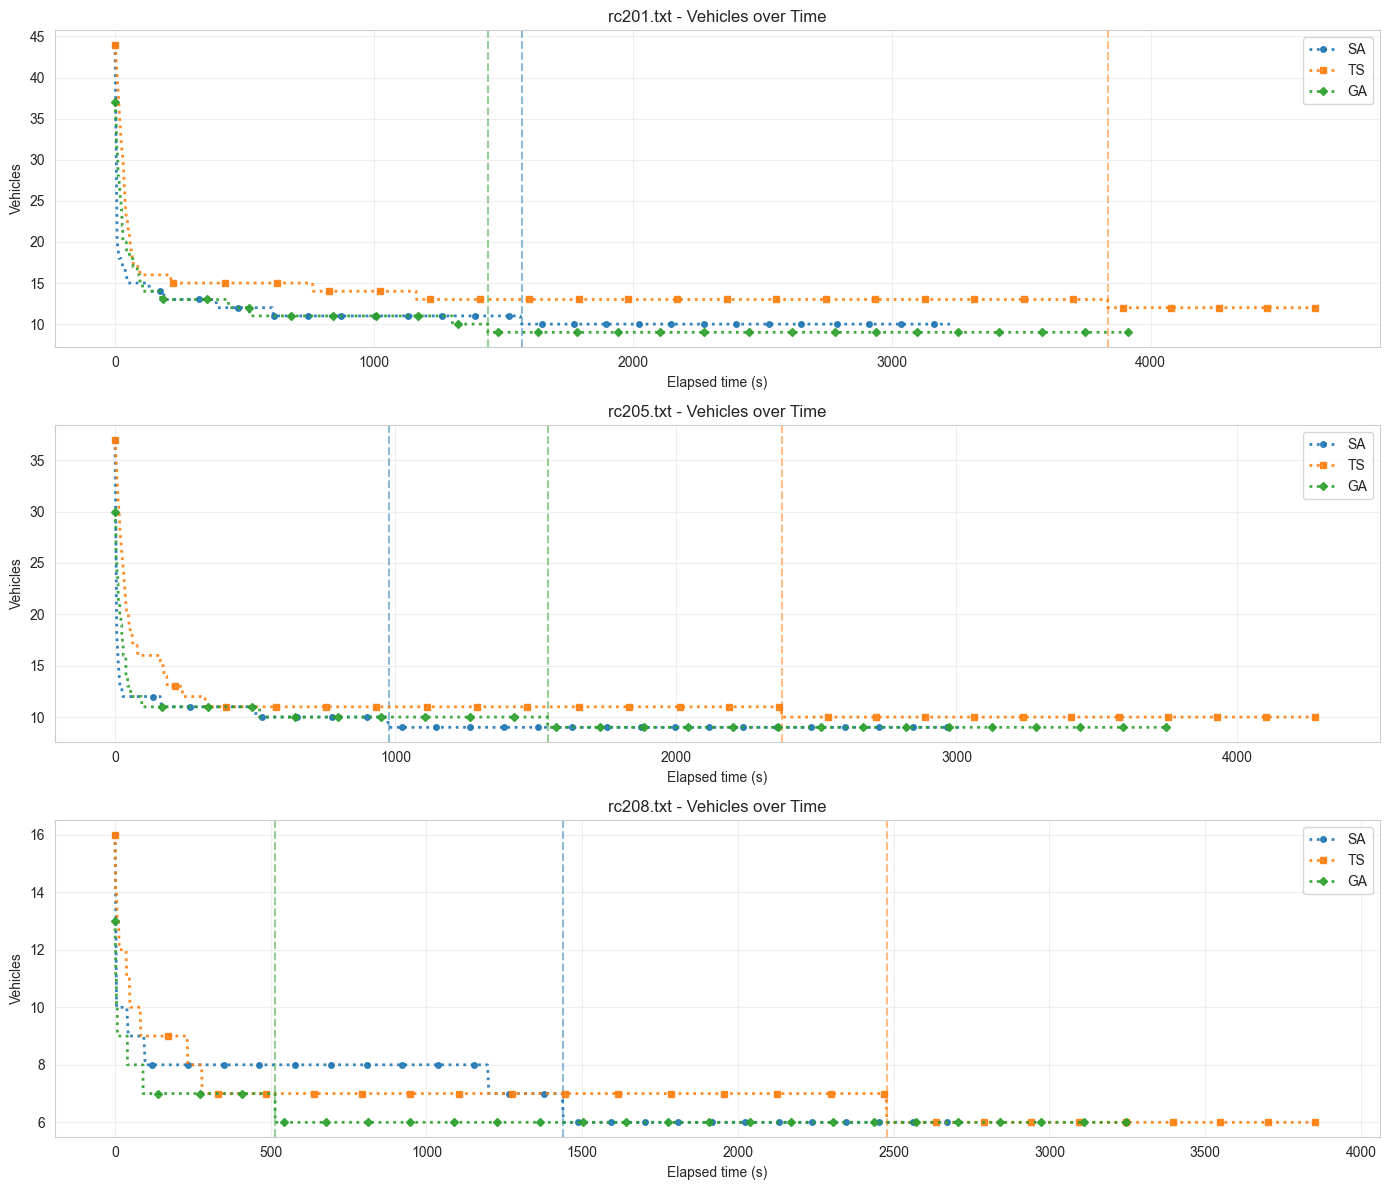

In [8]:
# Plot vehicle traces against elapsed time, with stagnation time marked.
fig, axes = plt.subplots(len(TEST_INSTANCES), 1, figsize=(14, 4 * len(TEST_INSTANCES)), sharex=False)
if len(TEST_INSTANCES) == 1:
    axes = [axes]

method_styles = [
    ("SA", "tab:blue", "o"),
    ("TS", "tab:orange", "s"),
    ("GA", "tab:green", "D")
]

for ax, instance_file in zip(axes, TEST_INSTANCES):
    for method_name, color, marker in method_styles:
        trace = trace_data[(instance_file, method_name)]
        ax.plot(
            trace["elapsed_sec"],
            trace["vehicles"],
            label=method_name,
            color=color,
            linestyle=":",
            linewidth=2,
            marker=marker,
            markersize=4,
            markevery=max(1, len(trace["elapsed_sec"]) // 24),
            alpha=0.9,
        )
        ax.axvline(trace["stagnation_time_sec"], color=color, linestyle="--", alpha=0.5)

    ax.set_title(f"{instance_file} - Vehicles over Time")
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel("Vehicles")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Key Insights Summary

In [9]:
print("\nKEY TAKEAWAYS")
print("- Stagnation is measured by time, not iteration.")
print("- It is the timestamp when the run first reaches its final best vehicle count and never improves after that.")
print("- Total runtime is reported per run and per method.")

best_by_method = df_results.groupby("method")["stagnation_time_sec"].mean().sort_values()
print("\nAverage stagnation time by method:")
for method_name, value in best_by_method.items():
    print(f"{method_name}: {value:.2f} s")


KEY TAKEAWAYS
- Stagnation is measured by time, not iteration.
- It is the timestamp when the run first reaches its final best vehicle count and never improves after that.
- Total runtime is reported per run and per method.

Average stagnation time by method:
GA: 1165.64 s
SA: 1328.59 s
TS: 2896.94 s


## Runtime Benchmark with MAS Inner Parameters

Run each metaheuristic independently (not cooperative MAS), but using the MAS inner parameter sets from `settings.py`.
This isolates how long each method takes with the same configuration used inside MAS agents.

In [10]:
import time
from pathlib import Path
import pandas as pd
from project import Dataset
from project.Metaheuristics import SimulatedAnnealing, TabuSearch, GeneticAlgorithm
from project import settings as cfg

# Keep this cell runnable even if previous setup cells were not executed yet.
if "DATASETS_DIR" not in globals():
    DATASETS_DIR = Path("../Datasets")
if "TEST_INSTANCES" not in globals():
    TEST_INSTANCES = list(cfg.INSTANCES) if hasattr(cfg, "INSTANCES") else ["rc201.txt", "rc205.txt", "rc208.txt"]
if "SEED_BASE" not in globals():
    SEED_BASE = cfg.SEED_START

MAS_METHODS = [
    ("SA", SimulatedAnnealing, cfg.MAS_SA_PARAMS),
    ("TS", TabuSearch, cfg.MAS_TS_PARAMS),
    ("GA", GeneticAlgorithm, cfg.MAS_GA_PARAMS),
]

mas_runtime_rows = []
benchmark_t0 = time.perf_counter()

print("=" * 90)
print("RUNTIME BENCHMARK | Isolated SA/TS/GA with MAS inner parameters")
print(f"Instances: {len(TEST_INSTANCES)} | Seed: {SEED_BASE}")
print(f"Methods: {[name for name, _, _ in MAS_METHODS]}")
print("=" * 90)

for i, instance_file in enumerate(TEST_INSTANCES, start=1):
    instance_t0 = time.perf_counter()
    dataset = Dataset(DATASETS_DIR / instance_file)
    print(f"\n[{i}/{len(TEST_INSTANCES)}] Instance: {instance_file}")
    print("-" * 90)

    for method_name, solver_cls, params in MAS_METHODS:
        method_t0 = time.perf_counter()
        print(f"  -> START {method_name}")

        solver = solver_cls(dataset, seed=SEED_BASE, **params)
        best_route = solver.solve()
        method_elapsed = time.perf_counter() - method_t0

        vehicles, distance = best_route.cost_function()
        mas_runtime_rows.append({
            "instance": instance_file,
            "method": method_name,
            "runtime_sec": float(method_elapsed),
            "vehicles": int(vehicles),
            "distance": float(distance),
        })

        print(
            f"  <- END   {method_name} | time={method_elapsed:8.2f}s | K={vehicles:2d} | D={distance:8.1f}"
        )

    instance_elapsed = time.perf_counter() - instance_t0
    print(f"Instance total time: {instance_elapsed:.2f}s")

df_mas_runtime = pd.DataFrame(mas_runtime_rows)

runtime_by_method = (
    df_mas_runtime.groupby("method", as_index=False)
    .agg(
        total_runtime_sec=("runtime_sec", "sum"),
        mean_runtime_sec=("runtime_sec", "mean"),
        std_runtime_sec=("runtime_sec", "std"),
        mean_vehicles=("vehicles", "mean"),
        mean_distance=("distance", "mean"),
    )
    .sort_values("mean_runtime_sec")
)

runtime_by_instance = (
    df_mas_runtime.pivot(index="instance", columns="method", values="runtime_sec")
    .sort_index()
)

benchmark_elapsed = time.perf_counter() - benchmark_t0
print("\n" + "=" * 90)
print(f"Benchmark finished in {benchmark_elapsed:.2f}s")
print("Fastest to slowest (mean runtime):")
for rank, row in enumerate(runtime_by_method.itertuples(index=False), start=1):
    print(f"  {rank}. {row.method} -> {row.mean_runtime_sec:.2f}s")
print("=" * 90)

print("\nRuntime summary by method (MAS params):")
display(runtime_by_method)

print("Runtime per instance and method (seconds):")
display(runtime_by_instance)

RUNTIME BENCHMARK | Isolated SA/TS/GA with MAS inner parameters
Instances: 3 | Seed: 1
Methods: ['SA', 'TS', 'GA']

[1/3] Instance: rc201.txt
------------------------------------------------------------------------------------------
  -> START SA
  <- END   SA | time=  218.32s | K=11 | D=  2210.5
  -> START TS
  <- END   TS | time=  271.77s | K=14 | D=  2261.3
  -> START GA
  <- END   GA | time=  273.41s | K=13 | D=  3738.0
Instance total time: 763.52s

[2/3] Instance: rc205.txt
------------------------------------------------------------------------------------------
  -> START SA
  <- END   SA | time=  209.73s | K=11 | D=  2003.5
  -> START TS
  <- END   TS | time=  256.10s | K=11 | D=  1922.0
  -> START GA
  <- END   GA | time=  249.48s | K=11 | D=  3598.4
Instance total time: 715.34s

[3/3] Instance: rc208.txt
------------------------------------------------------------------------------------------
  -> START SA
  <- END   SA | time=  181.70s | K= 7 | D=  1557.5
  -> START TS
  <-

,method,total_runtime_sec,mean_runtime_sec,std_runtime_sec,mean_vehicles,mean_distance
1,SA,609.749643,203.249881,19.151116,9.666667,1923.832480
0,GA,730.103950,243.367983,33.519821,10.333333,3410.406009
2,TS,745.722109,248.574036,27.735139,10.666667,1927.843764


Runtime per instance and method (seconds):


method,GA,SA,TS
instance,,,
rc201.txt,273.409847,218.317064,271.771462
rc205.txt,249.482170,209.734144,256.097235
rc208.txt,207.211933,181.698435,217.853411
